# 11.To implement image classification using CNN on the CIFAR-10 dataset.

## Image Classification Using CNN on the CIFAR-10 Dataset

### Aim

To implement image classification using a Convolutional Neural Network (CNN) on the CIFAR-10 dataset.

## Introduction

Image classification is the process of assigning an input image to one of several predefined classes.

A Convolutional Neural Network (CNN) is widely used for image classification because it can automatically learn important features such as edges, shapes, textures, and patterns from images.

In this practical, a CNN model is trained on the CIFAR-10 dataset to classify images into 10 different categories.

## CIFAR-10 Dataset

CIFAR-10 is a popular dataset used for image classification and computer vision tasks.

### Dataset Information

- Total Images: 60,000
- Training Images: 50,000
- Testing Images: 10,000
- Image Size: 32 × 32 pixels
- Image Channels: 3 (RGB)
- Number of Classes: 10

### Classes

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

## CNN Architecture

The CNN model used in this practical consists of:

- Convolution Layer
- ReLU Activation
- Max Pooling Layer
- Convolution Layer
- ReLU Activation
- Max Pooling Layer
- Flatten Layer
- Dense Layer
- Output Layer with Softmax Activation

## Algorithm

1. Import the required libraries.
2. Load the CIFAR-10 dataset.
3. Display sample images.
4. Normalize the pixel values.
5. Build the CNN model.
6. Display the model summary.
7. Compile the model.
8. Train the CNN model.
9. Evaluate the model using test data.
10. Predict the classes of test images.
11. Display predicted and actual labels.

In [1]:
#Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models

In [2]:
# Load CIFAR-10 Dataset

(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


In [3]:
#Define Class Names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

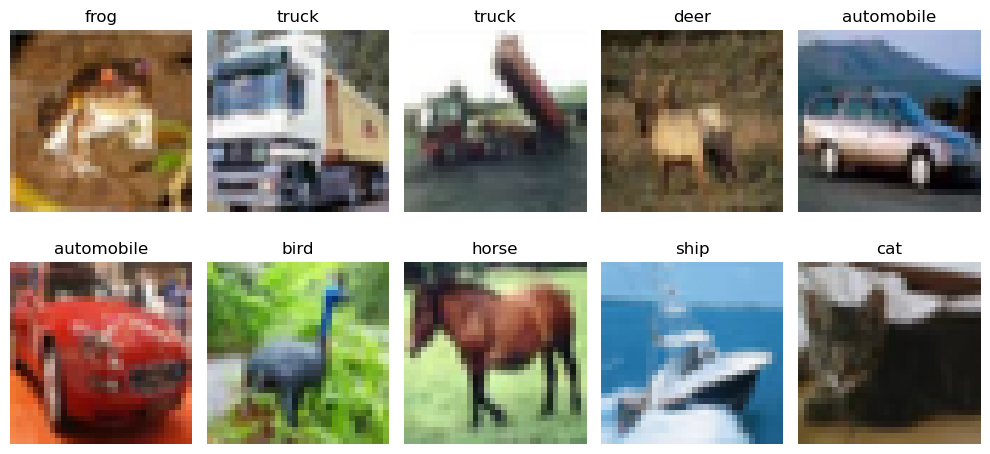

In [4]:
#Display Sample Images
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Data Preprocessing

The pixel values of CIFAR-10 images range from 0 to 255. To make the training process more efficient, the pixel values are normalized to a range between 0 and 1.

The normalized value is obtained by dividing each pixel value by 255.

In [5]:
# Normalize pixel values

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Data Normalization Completed")

Data Normalization Completed


In [6]:
#Build CNN Model

model = models.Sequential()

model.add(layers.Conv2D(
    32,
    (3, 3),
    activation='relu',
    input_shape=(32, 32, 3)
))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(
    64,
    (3, 3),
    activation='relu'
))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())

model.add(layers.Dense(
    128,
    activation='relu'
))

model.add(layers.Dense(
    10,
    activation='softmax'
))

C:\Users\Smit\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Model Compilation

The model is compiled using:

- **Adam:** Optimizer used to update the model weights.
- **Sparse Categorical Crossentropy:** Loss function used for multiclass classification.
- **Accuracy:** Evaluation metric used to measure classification performance.

In [8]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
#Train CNN Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3400 - loss: 1.7911 - val_accuracy: 0.5440 - val_loss: 1.2829
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5668 - loss: 1.2192 - val_accuracy: 0.6097 - val_loss: 1.1225
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.6314 - loss: 1.0560 - val_accuracy: 0.6241 - val_loss: 1.0826
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6658 - loss: 0.9562 - val_accuracy: 0.6605 - val_loss: 0.9762
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.6969 - loss: 0.8687 - val_accuracy: 0.6711 - val_loss: 0.9523
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7206 - loss: 0.7969 - val_accuracy: 0.6736 - val_loss: 0.9374
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7460 - loss: 0.7296 - val_accuracy: 0.6822 - val_loss: 0.9335
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.7652 - loss: 0.6786 - 

In [10]:
#Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6841 - loss: 0.9719
Test Loss : 0.9686555862426758
Test Accuracy : 0.6866000294685364


In [11]:
#Make Predictions
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted Label :", class_names[predicted_labels[0]])
print("Actual Label    :", class_names[y_test[0][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicted Label : cat
Actual Label    : cat


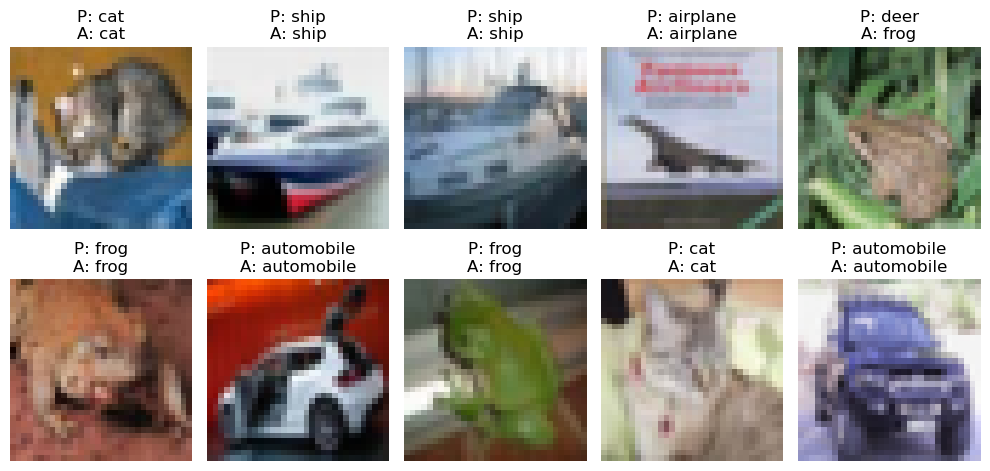

In [12]:
#Display Predictions
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    plt.imshow(X_test[i])
    
    predicted = class_names[predicted_labels[i]]
    actual = class_names[y_test[i][0]]
    
    plt.title(f"P: {predicted}\nA: {actual}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Expected Output

- CIFAR-10 training and testing datasets are loaded successfully.
- Sample RGB images from the dataset are displayed.
- CNN model architecture is displayed using `model.summary()`.
- The CNN model is trained for 10 epochs.
- Test accuracy is displayed.
- Predicted and actual class labels are displayed for sample test images.

## Observation

- The CNN learns important visual features from CIFAR-10 images.
- Convolution layers extract image features such as edges, shapes, and textures.
- Max Pooling reduces the spatial dimensions of feature maps.
- The Dense layer performs classification based on the extracted features.
- The Softmax output layer provides probabilities for the 10 classes.

## Result

Image classification using a Convolutional Neural Network (CNN) was successfully implemented on the CIFAR-10 dataset. The model was trained to classify RGB images into 10 different categories and its performance was evaluated using test data.